In [73]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cloudpickle
import base64
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from joblib import Parallel, delayed
from scipy.stats import vonmises_fisher, vonmises_line

## Functions

In [74]:
def spd_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'df', 'ai_i_cov', 'ai_ii_cov', 'ai_iii_cov', 'ai_iv_cov',
    'lc_i_cov', 'lc_ii_cov', 'lc_iii_cov', 'lc_iv_cov', 'le_i_cov', 'le_ii_cov', 'le_iii_cov', 'le_iv_cov',
    'ai_OOB_quantile', 'lc_OOB_quantile', 'le_OOB_quantile'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_SPD'), 'results')):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_SPD'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'df': file.split('_')[3][2:],
            'ai_i_cov': [result['ai_i_cov']],
            'ai_ii_cov': [result['ai_ii_cov']],
            'ai_iii_cov': [result['ai_iii_cov']],
            'ai_iv_cov': [result['ai_iv_cov']],
            'lc_i_cov': [result['lc_i_cov']],
            'lc_ii_cov': [result['lc_ii_cov']],
            'lc_iii_cov': [result['lc_iii_cov']],
            'lc_iv_cov': [result['lc_iv_cov']],
            'le_i_cov': [result['le_i_cov']],
            'le_ii_cov': [result['le_ii_cov']],
            'le_iii_cov': [result['le_iii_cov']],
            'le_iv_cov': [result['le_iv_cov']],
            'ai_OOB_quantile': [result['ai_OOB_quantile']],
            'lc_OOB_quantile': [result['lc_OOB_quantile']],
            'le_OOB_quantile': [result['le_OOB_quantile']]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['df'] = coverage_df.df.astype('category')
    return coverage_df

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters
q = 2

Prediction balls

In [75]:
# Define confidence levels
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
SPD_coverage_df=spd_coverage_results()
SPD_coverage_df.head()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73


,sample_index,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,lc_i_cov,lc_ii_cov,lc_iii_cov,lc_iv_cov,le_i_cov,le_ii_cov,le_iii_cov,le_iv_cov,ai_OOB_quantile,lc_OOB_quantile,le_OOB_quantile
0,16,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.968, 0.888]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.98, 0.944]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.948, 0.902]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.978, 0.956]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.946, 0.87]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.966, 0.942]","[1.9691326959495807, 1.2622588632653096, 1.061...","[1.0446398947934668, 0.7102772681383526, 0.631...","[1.9456604701684441, 1.1709583839141808, 1.037..."
1,12,50,5,"[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.968, 0.952, 0.93]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.968, 0.956]","[[1.0, 0.0, 0.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.998, 0.948, 0.884]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.93, 0.866]","[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.968, 0.94, 0.93]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.964, 0.958]","[2.729740778544328, 2.485029468196364, 2.27527...","[1.798336015213443, 1.2750916622012012, 1.1021...","[2.6827804317391677, 2.3815045299063176, 2.252..."
2,20,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.964, 0.94, 0.902]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.984, 0.966]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.944, 0.936, 0.898]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.986, 0.97]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.954, 0.944, 0.906]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.984, 0.966]","[1.4412353482881373, 1.3034633198846453, 1.169...","[0.7653130555974023, 0.7518993837815295, 0.674...","[1.3529335646101983, 1.2912131145240806, 1.148..."
3,19,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.966, 0.926, 0.868]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.972, 0.926, 0.84]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.972, 0.922, 0.864]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.974, 0.942, 0.906]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.968, 0.928, 0.86]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.972, 0.926, 0.852]","[1.3189555838626268, 1.1332996138637659, 0.986...","[0.7497831604894118, 0.6499121349099125, 0.587...","[1.290429405603894, 1.1144134480191537, 0.9872..."
4,14,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.95, 0.88]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.972, 0.918, 0.828]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.964, 0.89]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.984, 0.948, 0.852]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.96, 0.884]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.964, 0.924, 0.834]","[1.3735984237639198, 1.1836588717836662, 1.056...","[0.938555046181838, 0.7556771212067579, 0.6378...","[1.3087463641828514, 1.1934137904271958, 1.047..."


In [76]:
ai_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'ai_i_cov', 'ai_ii_cov', 'ai_iii_cov', 'ai_iv_cov', 'ai_OOB_quantile']]
lc_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'lc_i_cov', 'lc_ii_cov', 'lc_iii_cov', 'lc_iv_cov', 'lc_OOB_quantile']]
le_SPD_coverage_df = SPD_coverage_df[['train_size', 'df', 'le_i_cov', 'le_ii_cov', 'le_iii_cov', 'le_iv_cov', 'le_OOB_quantile']]

# TYPE I

In [77]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_i_coverage(SPD_coverage_df, sample_sizes, df_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    ai_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    lc_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    le_diccionario_i = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    for N in sample_sizes:
        for df in df_values:
            ai_means = []
            lc_means = []
            le_means = []
            ai_SPD_coverage_df_N_df = ai_SPD_coverage_df[(ai_SPD_coverage_df['df'] == str(df))
             & (ai_SPD_coverage_df['train_size'] == N)]
            lc_SPD_coverage_df_N_df = lc_SPD_coverage_df[(lc_SPD_coverage_df['df'] == str(df))
             & (lc_SPD_coverage_df['train_size'] == N)]
            le_SPD_coverage_df_N_df = le_SPD_coverage_df[(le_SPD_coverage_df['df'] == str(df))
             & (le_SPD_coverage_df['train_size'] == N)]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in SPD_coverage_df['i_cov']
                ai_row_data = ai_SPD_coverage_df_N_df['ai_i_cov'].apply(lambda df: df[i])
                lc_row_data = lc_SPD_coverage_df_N_df['lc_i_cov'].apply(lambda df: df[i])
                le_row_data = le_SPD_coverage_df_N_df['le_i_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                ai_row_mean = ai_row_data.mean(axis=0)
                lc_row_mean = lc_row_data.mean(axis=0)
                le_row_mean = le_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                ai_means.append(ai_row_mean)
                lc_means.append(lc_row_mean)
                le_means.append(le_row_mean)

            ai_diccionario_i['df_' + str(df)][str(N)] = ai_means
            lc_diccionario_i['df_' + str(df)][str(N)] = lc_means
            le_diccionario_i['df_' + str(df)][str(N)] = le_means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return ai_diccionario_i, lc_diccionario_i, le_diccionario_i

sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters

ai_diccionario_i, lc_diccionario_i, le_diccionario_i = calculate_type_i_coverage(SPD_coverage_df = SPD_coverage_df, sample_sizes = sample_sizes, df_values = df_values)
le_diccionario_i

{'df_5': {'50': [array([0.9, 0.9, 0.8]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([0.9, 0.9, 0.9]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.8]),
   array([0.9, 0.9, 0.9]),
   array([1. , 1. , 0.8]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.8]),
   array([1. , 1. , 0.8]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.9]),
   array([1. , 1. , 0.9]),
   array([1. , 0.8, 0.8]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.8]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.9]),
   array([1. , 0.8, 0.8]),
   array([0.9, 0.8, 0.7]),
   array([0.9, 0.9, 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.9]),
   array([1. , 0.9, 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 

Prediction balls

In [78]:
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

In [79]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_ai = np.mean(ai_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_ai = np.sqrt(np.var(ai_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_ai[i]:.2f} ({100*stds_ai[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
ai_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
ai_df

Significance Level          0.01           0.05            0.1
df N                                                          
5  50               98.20 (3.84)   94.40 (6.68)   90.20 (8.36)
   100              96.60 (5.14)   92.40 (7.89)  85.80 (10.60)
   200              98.20 (4.33)   93.80 (7.45)   88.40 (9.46)
   500              99.67 (2.33)  94.67 (10.77)  90.67 (12.98)
15 50               97.40 (5.22)   91.80 (7.92)   87.60 (9.07)
   100              97.20 (5.67)   93.80 (7.97)   89.00 (9.22)
   200              98.80 (4.31)   94.60 (7.80)   90.00 (9.80)
   500              98.75 (3.75)   95.00 (7.50)  89.25 (11.46)

In [80]:
# Apply formatting to all cells
ai_df = ai_df.applymap(format_cell)
ai_latex = ai_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:ai_typeIerrorcoverage')
print(ai_latex)

\begin{table}
\caption{Type I error}
\label{tab:ai_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.20 (3.84) & 94.40 (6.68) & 90.20 (8.36) \\
\textbf{} & \textbf{100} & 96.60 (5.14) & 92.40 (7.89) & 85.80 (10.60) \\
\textbf{} & \textbf{200} & 98.20 (4.33) & 93.80 (7.45) & 88.40 (9.46) \\
\textbf{} & \textbf{500} & 99.67 (2.33) & 94.67 (10.77) & 90.67 (12.98) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 97.40 (5.22) & 91.80 (7.92) & 87.60 (9.07) \\
\textbf{} & \textbf{100} & 97.20 (5.67) & 93.80 (7.97) & 89.00 (9.22) \\
\textbf{} & \textbf{200} & 98.80 (4.31) & 94.60 (7.80) & 90.00 (9.80) \\
\textbf{} & \textbf{500} & 98.75 (3.75) & 95.00 (7.50) & 89.25 (11.46) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/1377484444.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ai_df = ai_df.applymap(format_cell)


In [81]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_lc = np.mean(lc_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_lc = np.sqrt(np.var(lc_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_lc[i]:.2f} ({100*stds_lc[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
lc_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
lc_df

Significance Level           0.01          0.05            0.1
df N                                                          
5  50                98.80 (3.25)  93.40 (7.10)   87.80 (9.86)
   100               98.20 (3.84)  93.60 (7.14)  88.20 (10.71)
   200               98.00 (4.47)  93.80 (8.22)  87.60 (11.24)
   500              100.00 (0.00)  94.67 (9.09)  91.00 (13.42)
15 50                95.60 (6.05)  91.00 (7.81)   87.00 (8.77)
   100               98.00 (5.29)  94.00 (7.21)  87.00 (11.87)
   200               98.60 (3.47)  94.00 (7.75)   89.00 (9.85)
   500               99.00 (3.39)  95.25 (8.25)  89.25 (11.46)

In [82]:
# Apply formatting to all cells
lc_df = lc_df.applymap(format_cell)
lc_latex = lc_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:lc_typeIerrorcoverage')
print(lc_latex)

\begin{table}
\caption{Type I error}
\label{tab:lc_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.80 (3.25) & 93.40 (7.10) & 87.80 (9.86) \\
\textbf{} & \textbf{100} & 98.20 (3.84) & 93.60 (7.14) & 88.20 (10.71) \\
\textbf{} & \textbf{200} & 98.00 (4.47) & 93.80 (8.22) & 87.60 (11.24) \\
\textbf{} & \textbf{500} & 100.00 (0.00) & 94.67 (9.09) & 91.00 (13.42) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 95.60 (6.05) & 91.00 (7.81) & 87.00 (8.77) \\
\textbf{} & \textbf{100} & 98.00 (5.29) & 94.00 (7.21) & 87.00 (11.87) \\
\textbf{} & \textbf{200} & 98.60 (3.47) & 94.00 (7.75) & 89.00 (9.85) \\
\textbf{} & \textbf{500} & 99.00 (3.39) & 95.25 (8.25) & 89.25 (11.46) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/1770482267.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lc_df = lc_df.applymap(format_cell)


In [83]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_le = np.mean(le_diccionario_i[f'df_{df}'][str(N)], axis=0)
        stds_le = np.sqrt(np.var(le_diccionario_i[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_le[i]:.2f} ({100*stds_le[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
le_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
le_df

Significance Level          0.01           0.05            0.1
df N                                                          
5  50               98.20 (3.84)   95.40 (6.07)   90.20 (7.87)
   100              96.80 (5.08)   92.80 (7.76)  86.00 (10.39)
   200              98.40 (3.67)   93.20 (7.60)   87.00 (9.64)
   500              99.33 (3.27)  95.00 (10.67)  90.67 (12.98)
15 50               97.40 (5.22)   91.60 (7.58)   85.40 (8.99)
   100              97.00 (5.74)   93.40 (8.15)   89.20 (8.68)
   200              98.80 (4.31)   94.20 (7.24)   88.40 (9.67)
   500              99.00 (3.39)   94.50 (8.35)  89.25 (11.46)

In [84]:
# Apply formatting to all cells
le_df = le_df.applymap(format_cell)
le_latex = le_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:ai_typeIerrorcoverage')
print(le_latex)

\begin{table}
\caption{Type I error}
\label{tab:ai_typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.20 (3.84) & 95.40 (6.07) & 90.20 (7.87) \\
\textbf{} & \textbf{100} & 96.80 (5.08) & 92.80 (7.76) & 86.00 (10.39) \\
\textbf{} & \textbf{200} & 98.40 (3.67) & 93.20 (7.60) & 87.00 (9.64) \\
\textbf{} & \textbf{500} & 99.33 (3.27) & 95.00 (10.67) & 90.67 (12.98) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 97.40 (5.22) & 91.60 (7.58) & 85.40 (8.99) \\
\textbf{} & \textbf{100} & 97.00 (5.74) & 93.40 (8.15) & 89.20 (8.68) \\
\textbf{} & \textbf{200} & 98.80 (4.31) & 94.20 (7.24) & 88.40 (9.67) \\
\textbf{} & \textbf{500} & 99.00 (3.39) & 94.50 (8.35) & 89.25 (11.46) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/691899972.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  le_df = le_df.applymap(format_cell)


# TYPE II

### df 5

In [85]:
ai_ii_SPD_coverage_df_df_5_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_ii_SPD_coverage_df_df_5_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_ii_SPD_coverage_df_df_5_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()

lc_ii_SPD_coverage_df_df_5_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_ii_SPD_coverage_df_df_5_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_ii_SPD_coverage_df_df_5_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()

le_ii_SPD_coverage_df_df_5_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_ii_SPD_coverage_df_df_5_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_ii_SPD_coverage_df_df_5_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()

ai_ii_SPD_coverage_df_df_5_alpha_01['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[0])
ai_ii_SPD_coverage_df_df_5_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_ii_SPD_coverage_df_df_5_alpha_01['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[0])
lc_ii_SPD_coverage_df_df_5_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[0])

le_ii_SPD_coverage_df_df_5_alpha_01['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[0])
le_ii_SPD_coverage_df_df_5_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[0])

ai_ii_SPD_coverage_df_df_5_alpha_05['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[1])
ai_ii_SPD_coverage_df_df_5_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_ii_SPD_coverage_df_df_5_alpha_05['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[1])
lc_ii_SPD_coverage_df_df_5_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[1])

le_ii_SPD_coverage_df_df_5_alpha_05['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[1])
le_ii_SPD_coverage_df_df_5_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[1])

ai_ii_SPD_coverage_df_df_5_alpha_1['ai_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_ii_cov'].apply(lambda x: x[2])
ai_ii_SPD_coverage_df_df_5_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_ii_SPD_coverage_df_df_5_alpha_1['lc_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_ii_cov'].apply(lambda x: x[2])
lc_ii_SPD_coverage_df_df_5_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[2])

le_ii_SPD_coverage_df_df_5_alpha_1['le_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_ii_cov'].apply(lambda x: x[2])
le_ii_SPD_coverage_df_df_5_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[2])

ai_ii_SPD_coverage_df_df_5_alpha_01.head()
ai_ii_SPD_coverage_df_df_5_alpha_05.head()
ai_ii_SPD_coverage_df_df_5_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
1,50,5,"[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.930,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.968, 0.956]",2.275271
5,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.878,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.972, 0.938, 0.908]",1.939893
8,100,5,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...",0.834,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.91, 0.872]",1.896604
10,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.894,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.976, 0.942]",2.125455
11,100,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.854,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.956, 0.91]",1.921164


### df 15

In [86]:
ai_ii_SPD_coverage_df_df_15_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_ii_SPD_coverage_df_df_15_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_ii_SPD_coverage_df_df_15_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()

lc_ii_SPD_coverage_df_df_15_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_ii_SPD_coverage_df_df_15_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_ii_SPD_coverage_df_df_15_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()

le_ii_SPD_coverage_df_df_15_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_ii_SPD_coverage_df_df_15_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_ii_SPD_coverage_df_df_15_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()

ai_ii_SPD_coverage_df_df_15_alpha_01['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[0])
ai_ii_SPD_coverage_df_df_15_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_ii_SPD_coverage_df_df_15_alpha_01['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[0])
lc_ii_SPD_coverage_df_df_15_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[0])

le_ii_SPD_coverage_df_df_15_alpha_01['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[0])
le_ii_SPD_coverage_df_df_15_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[0])

ai_ii_SPD_coverage_df_df_15_alpha_05['ai_ii_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[1])
ai_ii_SPD_coverage_df_df_15_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_ii_SPD_coverage_df_df_15_alpha_05['lc_ii_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[1])
lc_ii_SPD_coverage_df_df_15_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[1])

le_ii_SPD_coverage_df_df_15_alpha_05['le_ii_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[1])
le_ii_SPD_coverage_df_df_15_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[1])

ai_ii_SPD_coverage_df_df_15_alpha_1['ai_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_ii_cov'].apply(lambda x: x[2])
ai_ii_SPD_coverage_df_df_15_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_ii_SPD_coverage_df_df_15_alpha_1['lc_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_ii_cov'].apply(lambda x: x[2])
lc_ii_SPD_coverage_df_df_15_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[2])

le_ii_SPD_coverage_df_df_15_alpha_1['le_ii_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_ii_cov'].apply(lambda x: x[2])
le_ii_SPD_coverage_df_df_15_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[2])

ai_ii_SPD_coverage_df_df_15_alpha_01.head()
ai_ii_SPD_coverage_df_df_15_alpha_05.head()
ai_ii_SPD_coverage_df_df_15_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
0,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.888,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.98, 0.944]",1.061574
2,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.902,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.984, 0.966]",1.169577
3,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.868,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.972, 0.926, 0.84]",0.986423
4,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.880,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.972, 0.918, 0.828]",1.056132
6,500,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.908,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.958, 0.892]",0.979976


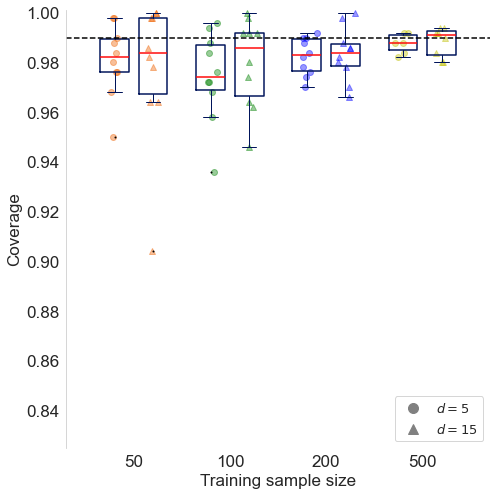

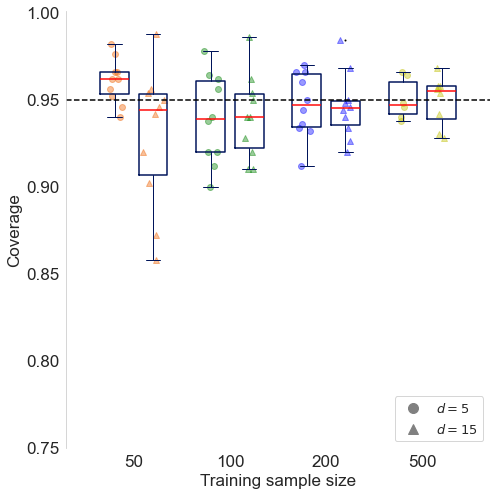

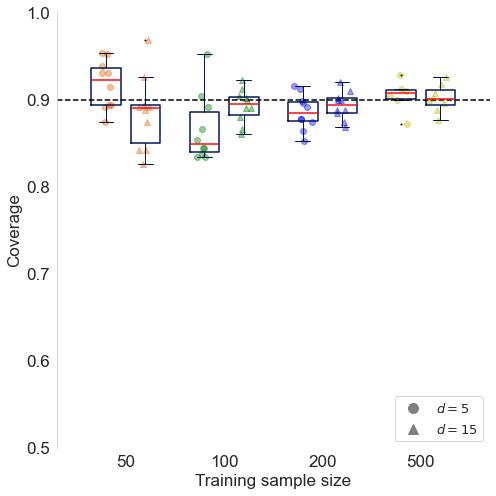

In [87]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for df_5_data, df_15_data, alpha_level in zip(
    [ai_ii_SPD_coverage_df_df_5_alpha_01, ai_ii_SPD_coverage_df_df_5_alpha_05, ai_ii_SPD_coverage_df_df_5_alpha_1], 
    [ai_ii_SPD_coverage_df_df_15_alpha_01, ai_ii_SPD_coverage_df_df_15_alpha_05, ai_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['ai_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['ai_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/ai_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

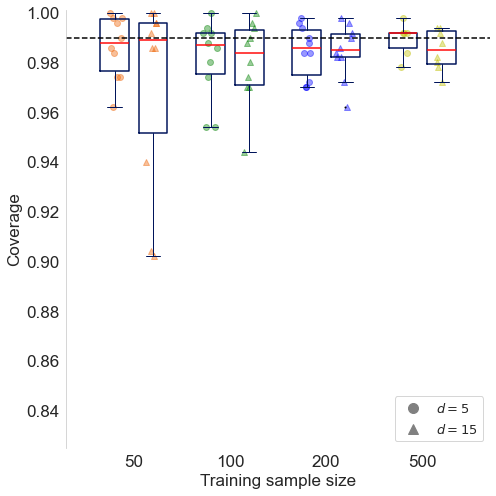

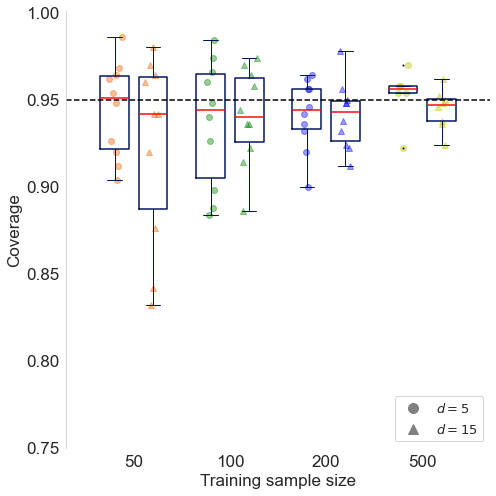

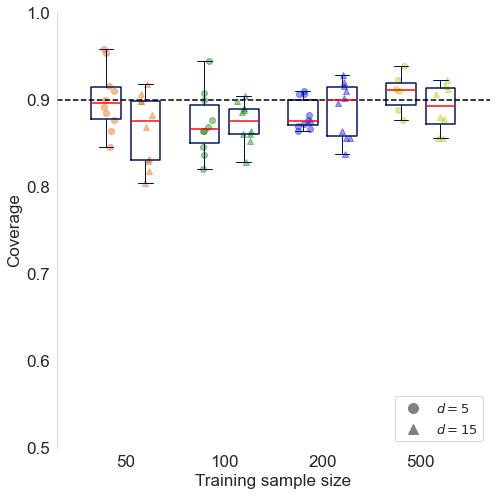

In [88]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for df_5_data, df_15_data, alpha_level in zip(
    [lc_ii_SPD_coverage_df_df_5_alpha_01, lc_ii_SPD_coverage_df_df_5_alpha_05, lc_ii_SPD_coverage_df_df_5_alpha_1], 
    [lc_ii_SPD_coverage_df_df_15_alpha_01, lc_ii_SPD_coverage_df_df_15_alpha_05, lc_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['lc_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['lc_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/lc_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

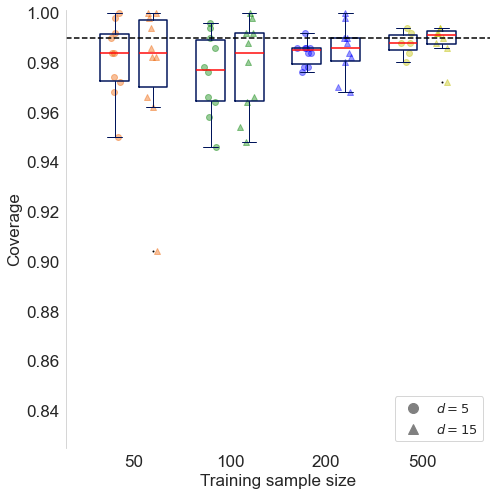

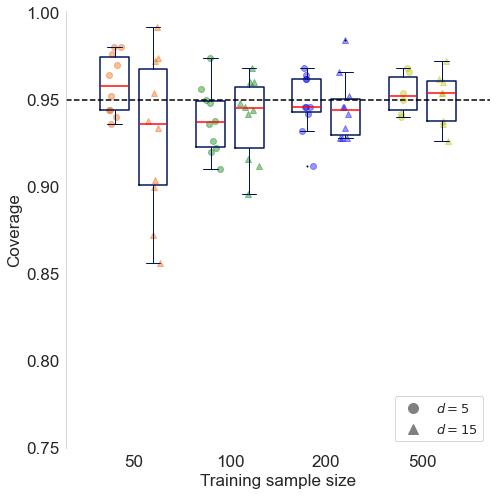

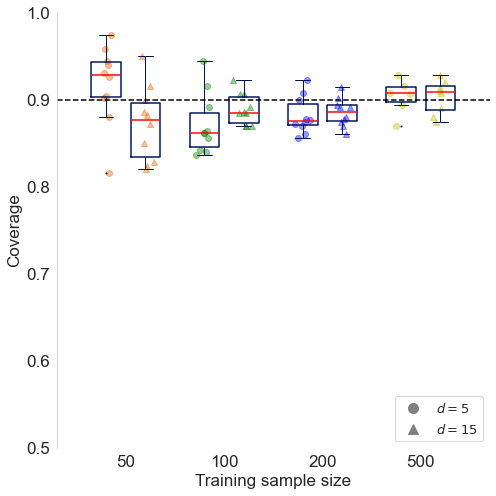

In [89]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for df_5_data, df_15_data, alpha_level in zip(
    [le_ii_SPD_coverage_df_df_5_alpha_01, le_ii_SPD_coverage_df_df_5_alpha_05, le_ii_SPD_coverage_df_df_5_alpha_1], 
    [le_ii_SPD_coverage_df_df_15_alpha_01, le_ii_SPD_coverage_df_df_15_alpha_05, le_ii_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [df_5_data[df_5_data['train_size'] == size]['le_ii_cov'].values for size in train_sizes]
    df_15_boxplot_data = [df_15_data[df_15_data['train_size'] == size]['le_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/le_df_5_15_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [90]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_iii_coverage(SPD_coverage_df, sample_sizes, df_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    ai_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    lc_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    le_diccionario_iii = {
    'df_5': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'df_15': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }
    for N in sample_sizes:
        for df in df_values:
            ai_means = []
            lc_means = []
            le_means = []
            ai_SPD_coverage_df_N_df = ai_SPD_coverage_df[(ai_SPD_coverage_df['df'] == str(df))
             & (ai_SPD_coverage_df['train_size'] == N)]
            lc_SPD_coverage_df_N_df = lc_SPD_coverage_df[(lc_SPD_coverage_df['df'] == str(df))
             & (lc_SPD_coverage_df['train_size'] == N)]
            le_SPD_coverage_df_N_df = le_SPD_coverage_df[(le_SPD_coverage_df['df'] == str(df))
             & (le_SPD_coverage_df['train_size'] == N)]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in SPD_coverage_df['i_cov']
                ai_row_data = ai_SPD_coverage_df_N_df['ai_iii_cov'].apply(lambda df: df[i])
                lc_row_data = lc_SPD_coverage_df_N_df['lc_iii_cov'].apply(lambda df: df[i])
                le_row_data = le_SPD_coverage_df_N_df['le_iii_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                ai_row_mean = ai_row_data.mean(axis=0)
                lc_row_mean = lc_row_data.mean(axis=0)
                le_row_mean = le_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                ai_means.append(ai_row_mean)
                lc_means.append(lc_row_mean)
                le_means.append(le_row_mean)

            ai_diccionario_iii['df_' + str(df)][str(N)] = ai_means
            lc_diccionario_iii['df_' + str(df)][str(N)] = lc_means
            le_diccionario_iii['df_' + str(df)][str(N)] = le_means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return ai_diccionario_iii, lc_diccionario_iii, le_diccionario_iii

sample_sizes = [50, 100, 200, 500]  # Sample sizes
df_values = [5, 15]  # Concentration parameters

ai_diccionario_iii, lc_diccionario_iii, le_diccionario_iii = calculate_type_iii_coverage(SPD_coverage_df = SPD_coverage_df, sample_sizes = sample_sizes, df_values = df_values)
le_diccionario_iii

{'df_5': {'50': [array([1. , 1. , 0.9]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.8]),
   array([0.9, 0.8, 0.8]),
   array([1. , 1. , 0.9]),
   array([1. , 1. , 0.9]),
   array([0.9, 0.7, 0.7]),
   array([1. , 0.9, 0.9]),
   array([1. , 0.9, 0.9]),
   array([0.9, 0.9, 0.9]),
   array([1. , 1. , 0.9]),
   array([0.9, 0.9, 0.8]),
   array([0.9, 0.9, 0.9]),
   array([1. , 0.9, 0.7]),
   array([1., 1., 1.]),
   array([1. , 0.9, 0.7]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([0.9, 0.9, 0.9]),
   array([0.9, 0.9, 0.9]),
   array([1. , 0.9, 0.9]),
   array([1. , 0.9, 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([0.9, 0.9, 0.9]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1., 1., 1.]),
   array([1. , 1. , 0.8]),
   array([1., 

Prediction balls

In [91]:
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

In [92]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_ai = np.mean(ai_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_ai = np.sqrt(np.var(ai_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_ai[i]:.2f} ({100*stds_ai[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
ai_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
ai_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.20 (3.84)  96.60 (6.20)   91.60 (9.02)
   100              98.00 (4.00)  94.40 (6.68)  88.40 (10.27)
   200              98.40 (3.67)  96.80 (5.08)   92.20 (8.55)
   500              98.67 (4.52)  94.33 (8.57)  90.67 (11.62)
15 50               99.60 (1.96)  96.80 (6.14)   95.20 (7.00)
   100              99.40 (2.37)  97.00 (5.74)   93.00 (9.43)
   200              99.40 (2.37)  96.00 (6.32)   90.40 (8.71)
   500              99.50 (2.45)  95.50 (6.00)  89.00 (11.36)

In [93]:
# Apply formatting to all cells
ai_df = ai_df.applymap(format_cell)
ai_latex = ai_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:ai_typeIIIerrorcoverage')
print(ai_latex)

\begin{table}
\caption{Type III error}
\label{tab:ai_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.20 (3.84) & 96.60 (6.20) & 91.60 (9.02) \\
\textbf{} & \textbf{100} & 98.00 (4.00) & 94.40 (6.68) & 88.40 (10.27) \\
\textbf{} & \textbf{200} & 98.40 (3.67) & 96.80 (5.08) & 92.20 (8.55) \\
\textbf{} & \textbf{500} & 98.67 (4.52) & 94.33 (8.57) & 90.67 (11.62) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.60 (1.96) & 96.80 (6.14) & 95.20 (7.00) \\
\textbf{} & \textbf{100} & 99.40 (2.37) & 97.00 (5.74) & 93.00 (9.43) \\
\textbf{} & \textbf{200} & 99.40 (2.37) & 96.00 (6.32) & 90.40 (8.71) \\
\textbf{} & \textbf{500} & 99.50 (2.45) & 95.50 (6.00) & 89.00 (11.36) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/2564002804.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ai_df = ai_df.applymap(format_cell)


In [94]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_lc = np.mean(lc_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_lc = np.sqrt(np.var(lc_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_lc[i]:.2f} ({100*stds_lc[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
lc_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
lc_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.80 (3.25)  93.20 (7.05)   88.80 (9.52)
   100              97.80 (4.14)  93.80 (6.90)   88.20 (9.94)
   200              97.80 (4.60)  93.80 (7.45)   88.80 (9.93)
   500              99.00 (3.96)  94.00 (8.67)  88.67 (12.67)
15 50               99.40 (2.37)  97.80 (4.14)   94.60 (7.54)
   100              99.60 (1.96)  97.60 (5.85)   92.80 (8.73)
   200              99.40 (2.37)  95.60 (6.05)   89.40 (9.68)
   500              98.00 (4.58)  94.25 (6.23)   88.00 (9.67)

In [95]:
# Apply formatting to all cells
lc_df = lc_df.applymap(format_cell)
lc_latex = lc_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:lc_typeIIIerrorcoverage')
print(lc_latex)

\begin{table}
\caption{Type III error}
\label{tab:lc_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.80 (3.25) & 93.20 (7.05) & 88.80 (9.52) \\
\textbf{} & \textbf{100} & 97.80 (4.14) & 93.80 (6.90) & 88.20 (9.94) \\
\textbf{} & \textbf{200} & 97.80 (4.60) & 93.80 (7.45) & 88.80 (9.93) \\
\textbf{} & \textbf{500} & 99.00 (3.96) & 94.00 (8.67) & 88.67 (12.67) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.40 (2.37) & 97.80 (4.14) & 94.60 (7.54) \\
\textbf{} & \textbf{100} & 99.60 (1.96) & 97.60 (5.85) & 92.80 (8.73) \\
\textbf{} & \textbf{200} & 99.40 (2.37) & 95.60 (6.05) & 89.40 (9.68) \\
\textbf{} & \textbf{500} & 98.00 (4.58) & 94.25 (6.23) & 88.00 (9.67) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/587411137.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  lc_df = lc_df.applymap(format_cell)


In [96]:
# Prepare data for the DataFrame
rows = []
index = []

for df in [5, 15]:
    for N in [50, 100, 200, 500]:
        row = []
        means_le = np.mean(le_diccionario_iii[f'df_{df}'][str(N)], axis=0)
        stds_le = np.sqrt(np.var(le_diccionario_iii[f'df_{df}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means_le[i]:.2f} ({100*stds_le[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{df}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["df", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
le_df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
le_df

Significance Level          0.01          0.05            0.1
df N                                                         
5  50               98.40 (3.67)  96.60 (6.20)   91.80 (9.53)
   100              98.20 (3.84)  94.40 (6.68)   89.20 (9.77)
   200              98.60 (3.47)  96.60 (5.14)   90.80 (9.13)
   500              98.67 (4.52)  94.67 (8.46)  90.33 (11.59)
15 50               99.60 (2.80)  96.60 (5.52)   93.80 (7.18)
   100              99.40 (2.37)  96.00 (6.32)   92.20 (8.78)
   200              99.60 (1.96)  96.40 (6.86)   89.20 (9.35)
   500              99.50 (2.45)  94.75 (6.66)  89.00 (11.08)

In [97]:
# Apply formatting to all cells
le_df = le_df.applymap(format_cell)
le_latex = le_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:ai_typeIIIerrorcoverage')
print(le_latex)

\begin{table}
\caption{Type III error}
\label{tab:ai_typeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
df & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{5}} & \textbf{50} & 98.40 (3.67) & 96.60 (6.20) & 91.80 (9.53) \\
\textbf{} & \textbf{100} & 98.20 (3.84) & 94.40 (6.68) & 89.20 (9.77) \\
\textbf{} & \textbf{200} & 98.60 (3.47) & 96.60 (5.14) & 90.80 (9.13) \\
\textbf{} & \textbf{500} & 98.67 (4.52) & 94.67 (8.46) & 90.33 (11.59) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{15}} & \textbf{50} & 99.60 (2.80) & 96.60 (5.52) & 93.80 (7.18) \\
\textbf{} & \textbf{100} & 99.40 (2.37) & 96.00 (6.32) & 92.20 (8.78) \\
\textbf{} & \textbf{200} & 99.60 (1.96) & 96.40 (6.86) & 89.20 (9.35) \\
\textbf{} & \textbf{500} & 99.50 (2.45) & 94.75 (6.66) & 89.00 (11.08) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_49230/142898499.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  le_df = le_df.applymap(format_cell)


# Type IV

Hacemos todo con $X=0.25$.

### df 5

In [98]:
ai_iv_SPD_coverage_df_df_5_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_iv_SPD_coverage_df_df_5_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()
ai_iv_SPD_coverage_df_df_5_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5'].copy()

lc_iv_SPD_coverage_df_df_5_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_iv_SPD_coverage_df_df_5_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()
lc_iv_SPD_coverage_df_df_5_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5'].copy()

le_iv_SPD_coverage_df_df_5_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_iv_SPD_coverage_df_df_5_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()
le_iv_SPD_coverage_df_df_5_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5'].copy()

ai_iv_SPD_coverage_df_df_5_alpha_01['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[0])
ai_iv_SPD_coverage_df_df_5_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_iv_SPD_coverage_df_df_5_alpha_01['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[0])
lc_iv_SPD_coverage_df_df_5_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[0])

le_iv_SPD_coverage_df_df_5_alpha_01['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[0])
le_iv_SPD_coverage_df_df_5_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[0])

ai_iv_SPD_coverage_df_df_5_alpha_05['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[1])
ai_iv_SPD_coverage_df_df_5_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_iv_SPD_coverage_df_df_5_alpha_05['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[1])
lc_iv_SPD_coverage_df_df_5_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[1])

le_iv_SPD_coverage_df_df_5_alpha_05['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[1])
le_iv_SPD_coverage_df_df_5_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[1])

ai_iv_SPD_coverage_df_df_5_alpha_1['ai_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_iv_cov'].apply(lambda x: x[2])
ai_iv_SPD_coverage_df_df_5_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_iv_SPD_coverage_df_df_5_alpha_1['lc_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_iv_cov'].apply(lambda x: x[2])
lc_iv_SPD_coverage_df_df_5_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['lc_OOB_quantile'].apply(lambda x: x[2])

le_iv_SPD_coverage_df_df_5_alpha_1['le_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_iv_cov'].apply(lambda x: x[2])
le_iv_SPD_coverage_df_df_5_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '5']['le_OOB_quantile'].apply(lambda x: x[2])

ai_iv_SPD_coverage_df_df_5_alpha_01.head()
ai_iv_SPD_coverage_df_df_5_alpha_05.head()
ai_iv_SPD_coverage_df_df_5_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
1,50,5,"[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.968, 0.952, 0.93]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.956,2.275271
5,200,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.95, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.908,1.939893
8,100,5,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.984, 0.92, 0.834]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.872,1.896604
10,50,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.962, 0.894]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.942,2.125455
11,100,5,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.912, 0.854]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.910,1.921164


## df 15

In [99]:
ai_iv_SPD_coverage_df_df_15_alpha_01 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_iv_SPD_coverage_df_df_15_alpha_05 = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()
ai_iv_SPD_coverage_df_df_15_alpha_1  = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15'].copy()

lc_iv_SPD_coverage_df_df_15_alpha_01 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_iv_SPD_coverage_df_df_15_alpha_05 = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()
lc_iv_SPD_coverage_df_df_15_alpha_1  = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15'].copy()

le_iv_SPD_coverage_df_df_15_alpha_01 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_iv_SPD_coverage_df_df_15_alpha_05 = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()
le_iv_SPD_coverage_df_df_15_alpha_1  = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15'].copy()

ai_iv_SPD_coverage_df_df_15_alpha_01['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[0])
ai_iv_SPD_coverage_df_df_15_alpha_01['ai_OOB_quantile'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[0])

lc_iv_SPD_coverage_df_df_15_alpha_01['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[0])
lc_iv_SPD_coverage_df_df_15_alpha_01['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[0])

le_iv_SPD_coverage_df_df_15_alpha_01['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[0])
le_iv_SPD_coverage_df_df_15_alpha_01['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[0])

ai_iv_SPD_coverage_df_df_15_alpha_05['ai_iv_cov'] = ai_SPD_coverage_df[ai_SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[1])
ai_iv_SPD_coverage_df_df_15_alpha_05['ai_OOB_quantile'] = ai_SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[1])

lc_iv_SPD_coverage_df_df_15_alpha_05['lc_iv_cov'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[1])
lc_iv_SPD_coverage_df_df_15_alpha_05['lc_OOB_quantile'] = lc_SPD_coverage_df[lc_SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[1])

le_iv_SPD_coverage_df_df_15_alpha_05['le_iv_cov'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[1])
le_iv_SPD_coverage_df_df_15_alpha_05['le_OOB_quantile'] = le_SPD_coverage_df[le_SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[1])

ai_iv_SPD_coverage_df_df_15_alpha_1['ai_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_iv_cov'].apply(lambda x: x[2])
ai_iv_SPD_coverage_df_df_15_alpha_1['ai_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['ai_OOB_quantile'].apply(lambda x: x[2])

lc_iv_SPD_coverage_df_df_15_alpha_1['lc_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_iv_cov'].apply(lambda x: x[2])
lc_iv_SPD_coverage_df_df_15_alpha_1['lc_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['lc_OOB_quantile'].apply(lambda x: x[2])

le_iv_SPD_coverage_df_df_15_alpha_1['le_iv_cov'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_iv_cov'].apply(lambda x: x[2])
le_iv_SPD_coverage_df_df_15_alpha_1['le_OOB_quantile'] = SPD_coverage_df[SPD_coverage_df['df'] == '15']['le_OOB_quantile'].apply(lambda x: x[2])

ai_iv_SPD_coverage_df_df_15_alpha_01.head()
ai_iv_SPD_coverage_df_df_15_alpha_05.head()
ai_iv_SPD_coverage_df_df_15_alpha_1.head()

,train_size,df,ai_i_cov,ai_ii_cov,ai_iii_cov,ai_iv_cov,ai_OOB_quantile
0,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.968, 0.888]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.944,1.061574
2,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.964, 0.94, 0.902]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.966,1.169577
3,200,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.966, 0.926, 0.868]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.840,0.986423
4,100,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.95, 0.88]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.828,1.056132
6,500,15,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.958, 0.908]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.892,0.979976


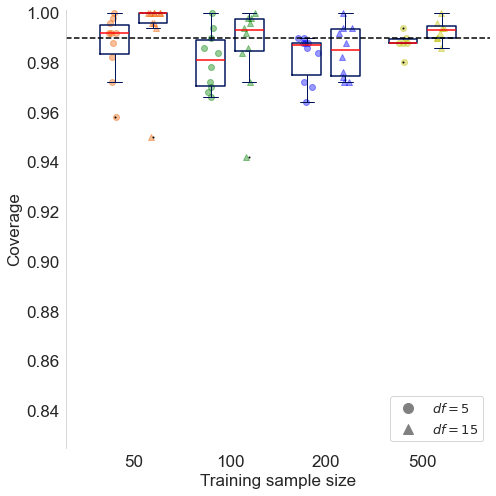

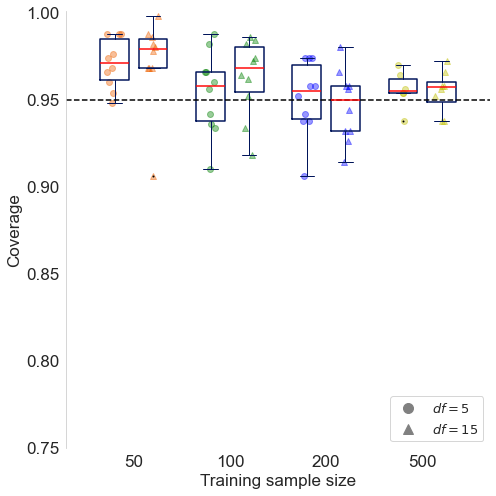

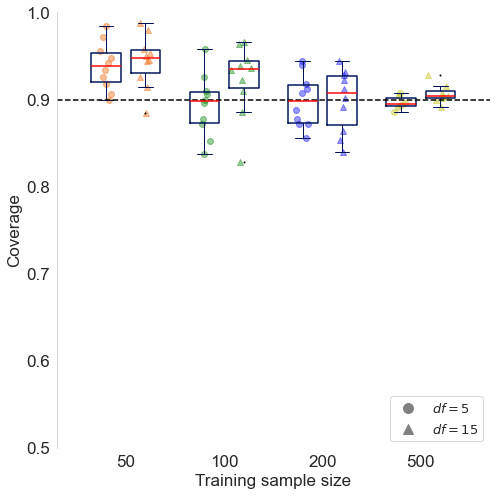

In [100]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [ai_iv_SPD_coverage_df_df_5_alpha_01, ai_iv_SPD_coverage_df_df_5_alpha_05, ai_iv_SPD_coverage_df_df_5_alpha_1],
    [ai_iv_SPD_coverage_df_df_15_alpha_01, ai_iv_SPD_coverage_df_df_15_alpha_05, ai_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['ai_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['ai_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$df = 5$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$df = 15$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/ai_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

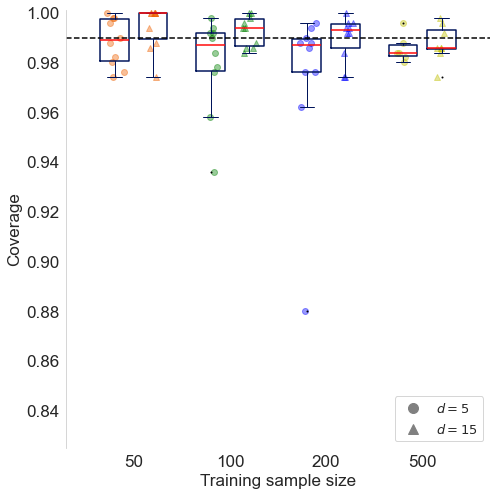

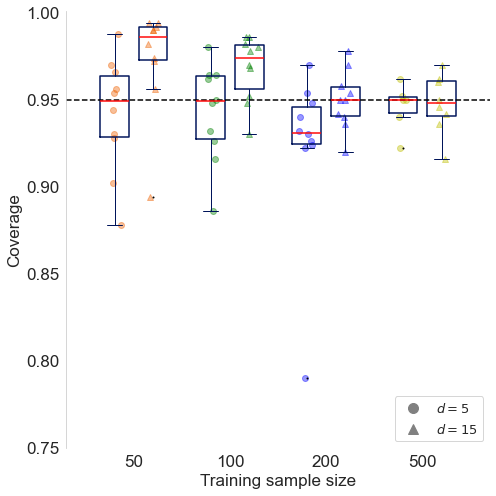

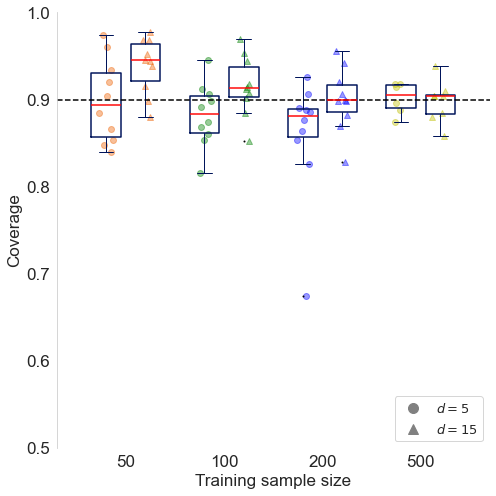

In [101]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [lc_iv_SPD_coverage_df_df_5_alpha_01, lc_iv_SPD_coverage_df_df_5_alpha_05, lc_iv_SPD_coverage_df_df_5_alpha_1],
    [lc_iv_SPD_coverage_df_df_15_alpha_01, lc_iv_SPD_coverage_df_df_15_alpha_05, lc_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['lc_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['lc_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$d = 5$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$d = 15$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/lc_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

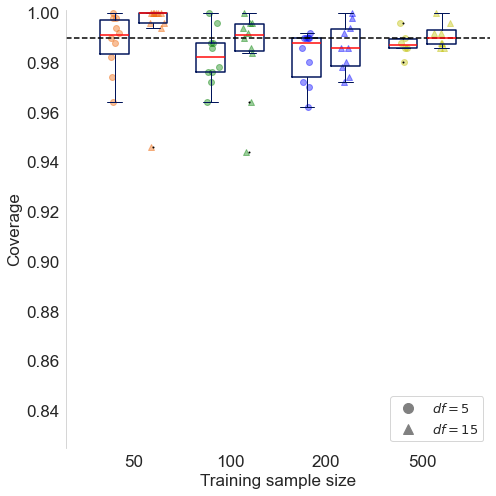

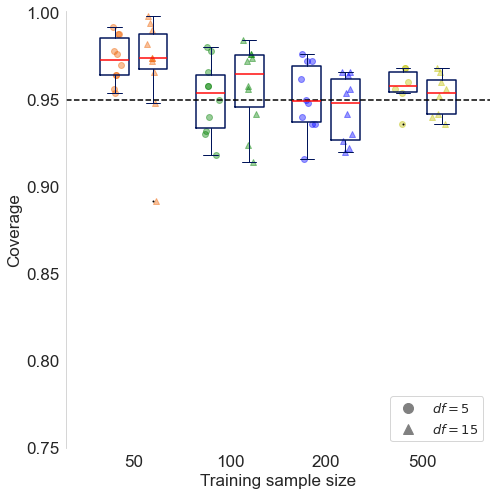

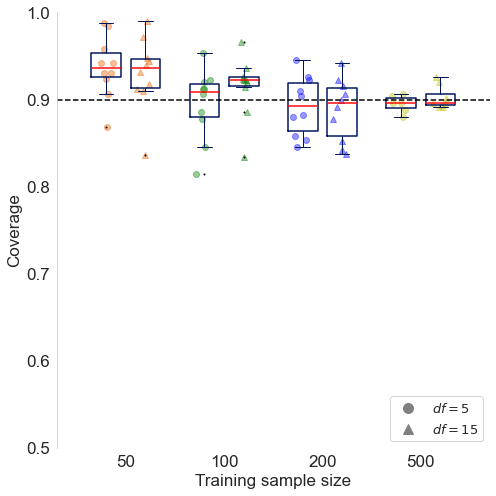

In [102]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data_5, data_15, alpha_level in zip(
    [le_iv_SPD_coverage_df_df_5_alpha_01, le_iv_SPD_coverage_df_df_5_alpha_05, le_iv_SPD_coverage_df_df_5_alpha_1],
    [le_iv_SPD_coverage_df_df_15_alpha_01, le_iv_SPD_coverage_df_df_15_alpha_05, le_iv_SPD_coverage_df_df_15_alpha_1], 
    [0.01, 0.05, 0.1]):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    df_5_boxplot_data = [data_5[data_5['train_size'] == size]['le_iv_cov'].values for size in train_sizes]
    df_15_boxplot_data = [data_15[data_15['train_size'] == size]['le_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_df_5 = np.array(range(len(train_sizes))) - 0.2
    positions_df_15 = np.array(range(len(train_sizes))) + 0.2

    sns.set_style("whitegrid")  # "white","dark","darkgrid","ticks"
    
    ax.boxplot(df_5_boxplot_data, positions=positions_df_5, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(df_15_boxplot_data, positions=positions_df_15, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_df_5 = ['#ee6100', 'g', 'b', 'y']
    palette_df_15 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_df_5 = np.random.normal(positions_df_5[i], 0.04, len(df_5_boxplot_data[i]))
        xs_df_15 = np.random.normal(positions_df_15[i], 0.04, len(df_15_boxplot_data[i]))

        ax.scatter(xs_df_5, df_5_boxplot_data[i], alpha=0.4, color=palette_df_5[i], label='Prediction balls')
        ax.scatter(xs_df_15, df_15_boxplot_data[i], alpha=0.4, color=palette_df_15[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1.001)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$df = 5$'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$df = 15$'),
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'simulations_SPD/le_df_5_15_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

In [103]:
# Define the matrices to interpolate 
Sigma_1 = np.array([[1, -0.6],
                  [-0.6, 0.5]])
Sigma_2 = np.array([[1, 0],
                  [0, 1]])
Sigma_3 = np.array([[0.5, 0.4],
                  [0.4, 1]])

In [104]:
def Sigma_t(t_array, Sigma_array):
    """Provides an array with the matrices given by a regression model that interpolates between four matrices."""  
    """In [0,1], the regression starts with Sigma_1 and then goes to Sigma_2 and Sigma_3."""
    """In general, the regression oscillates between Sigma_1, Sigma_2 and Sigma_3."""
    
    # Define time intervals for interpolation
    t_array = np.array(t_array)
    t_array = t_array[:, None, None]
    # Return the interpolated matrices
    return np.where(np.floor(t_array + 1/2) % 2 == 0, np.cos(np.pi*t_array)**2 * Sigma_array[0] + (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1], 0) + np.where(np.floor(t_array + 1/2) % 2 == 1, (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1] + np.cos(np.pi*t_array)**2 * Sigma_array[2], 0)

def sim_regression_matrices(Sigmas: tuple,
                            t: np.array,
                            df: int=2):
    t = np.array(t)
    q = Sigmas[0].shape[0]
    c_dq = 2 * np.exp((1 / q) * sum( digamma((df - np.arange(1, q + 1) + 1 ) / 2) ))

    sigma_t = Sigma_t(t=t, Sigmas=(Sigma_1, Sigma_2, Sigma_3))
    sample_Y = [wishart( df=df, scale = sigma_t[k]/c_dq ).rvs(size=1) for k in range(t.shape[0])]
    return {'t': t, 'y': sample_Y}

In [105]:
def old_Sigma_t(t_array, Sigma_array):
    """Provides an array with the matrices given by a regression model that interpolates between four matrices."""  
    """The regression starts with Sigma_1 and then goes to Sigma_2 and Sigma_3 and ends in Sigma_4."""
    
    # Define time intervals for interpolation
    t_array = np.array(t_array)
    t_array = t_array[:, None, None]
    # Return the interpolated matrices
    return np.where(t_array < 1/2, np.cos(np.pi*t_array)**2 * Sigma_array[0] + (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1], 0) + np.where(t_array >= 1/2, (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1] + np.cos(np.pi*t_array)**2 * Sigma_array[2], 0)

In [106]:
(Sigma_1, Sigma_2, Sigma_3)

(array([[ 1. , -0.6],
        [-0.6,  0.5]]),
 array([[1, 0],
        [0, 1]]),
 array([[0.5, 0.4],
        [0.4, 1. ]]))

In [107]:
t = np.linspace(0,2,201)
Sigma_t(t_array=t, Sigma_array=(Sigma_1, Sigma_2, Sigma_3))[200]

array([[ 1. , -0.6],
       [-0.6,  0.5]])

In [108]:
t = np.linspace(0,1,101)
old_Sigma_t(t_array=t, Sigma_array=(Sigma_1, Sigma_2, Sigma_3))[87]

array([[0.57886322, 0.33690942],
       [0.33690942, 1.        ]])